In [87]:
import sqlite3

In [88]:
def run_query(sql, description=""):
    conn = sqlite3.connect('college.db')

    df_result = pd.read_sql_query(sql, conn)
    conn.close()
    if description:
        print(description)
    return df_result

In [89]:
import pandas as pd

In [90]:
import matplotlib.pyplot as plt

In [91]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()

In [92]:
df = pd.read_csv('student_performance.csv')
df.to_sql('students', conn, if_exists='replace', index=False)

result = pd.read_sql_query("SELECT * FROM students LIMIT 5", conn)

conn.close()

In [93]:
df=pd.read_csv('student_performance.csv')

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"column :{df.columns.tolist()}")
print("first 3 rows:")
df.head(3)

Number of rows: 30
Number of columns: 13
column :['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']
first 3 rows:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [94]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql('students', conn, if_exists='replace', index=False)
cursor.execute("select count(*)from students")
count=cursor.fetchone()[0]
print(f"database 'college.db'created")
print(f"table'students'created")
print(f"total students:{count}")
cursor.execute("PRAGMA table_info(students)")
columns_info=cursor.fetchall()
print("table structure of 'students': ")
print(f"{'column Name':<25}{'data type':<12}")
print("-"*38)
for col in columns_info:
  print(f"{col[1]:<25}{col[2]:<12}")

database 'college.db'created
table'students'created
total students:30
table structure of 'students': 
column Name              data type   
--------------------------------------
student_id               INTEGER     
name                     TEXT        
age                      INTEGER     
gender                   TEXT        
department               TEXT        
semester                 INTEGER     
math_score               INTEGER     
science_score            INTEGER     
english_score            INTEGER     
programming_score        INTEGER     
attendance_percentage    INTEGER     
city                     TEXT        
admission_year           INTEGER     


In [95]:
sql_query = "SELECT * FROM students ORDER BY student_id DESC LIMIT 5"
description = "Last 5 entries in the 'students' table:"
result = run_query(sql_query, description)
display(result)

Last 5 entries in the 'students' table:


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023
1,1029,Nitin Jain,20,Male,Mechanical,2,75,76,70,50,84,Indore,2023
2,1028,Sunita Pillai,19,Female,Civil,2,60,65,68,39,73,Thiruvananthapuram,2023
3,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023
4,1026,Rekha Nair,20,Female,Electronics,2,72,77,73,63,82,Kochi,2023


In [96]:
query= "SELECT programming_score FROM students WHERE programming_score > 50 AND programming_score <= 75 ORDER BY student_id ASC"
result = run_query(query, description='Programming scores for students above 50 and less than or equal to 75:')
display(result)

Programming scores for students above 50 and less than or equal to 75:


,programming_score
0,55
1,52
2,72
3,51
4,69
5,58
6,53
7,63


In [97]:
query2="""select name,department,math_score
          from students
          order by math_score desc
          limit 5
        """
description = "Top 5 students by math score:"

display(result_query2)

,name,department,math_score
0,Ananya Das,Computer Science,95
1,Tanvi Mehta,Computer Science,93
2,Arjun Nair,Computer Science,92
3,Akanksha Yadav,Computer Science,91
4,Swati Kulkarni,Computer Science,90


In [98]:
max_programming_dept_query = """SELECT department, MAX(programming_score) as max_score
                            FROM students
                            GROUP BY department
                            ORDER BY max_score DESC
                            LIMIT 1"""
result_max_dept = run_query(max_programming_dept_query, description="Department with the highest programming score:")
display(result_max_dept)

Department with the highest programming score:


,department,max_score
0,Computer Science,97


In [99]:
student_highest_programming_query = """SELECT name, department, programming_score
                                   FROM students
                                   ORDER BY programming_score DESC
                                   LIMIT 1"""
result_highest_student = run_query(student_highest_programming_query, description="Student with the highest programming score:")
display(result_highest_student)

Student with the highest programming score:


,name,department,programming_score
0,Ananya Das,Computer Science,97


In [100]:
query_low_attendance = "SELECT * FROM students WHERE attendance_percentage !=75 "
description_low_attendance = "Students with attendance percentage above 75% :"
result_low_attendance = run_query(query_low_attendance, description_low_attendance)
display(result_low_attendance)

Students with attendance percentage above 75% :


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
5,1006,Meera Joshi,20,Female,Electronics,2,58,66,70,52,72,Pune,2023
6,1007,Kiran Kumar,21,Male,Civil,2,73,69,65,40,85,Bangalore,2023
7,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
8,1009,Rahul Mishra,20,Male,Mechanical,2,62,71,58,45,68,Varanasi,2023
9,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023


In [101]:
import pandas as pd

dept_data={
    'dept_code' :['cs','ec','mech','civil'],
    'dept_name':['computer science','electronics','mechanical','civil'],
    'hod_name' :['dr.shyam','dr.soorya','dr.subasssshh','dr.pullikutty'],
    'established':[1985,1988,1972,1965],
    'intake':[60,60,60,60]
}

dept_df=pd.DataFrame(dept_data)
dept_df.to_sql('departments', conn, if_exists='replace', index=False)

print("Created 'department table:")
print(dept_df.to_string(index=False))

dept_map={
    'computer science ':'cs',
    'electronics':'ec',
    'mechanical': 'mech',
    'civil':'civil'
}
df['department']=df['department'].map(dept_map)
df.to_sql('students', conn, if_exists='replace', index=False)




Created 'department table:
dept_code        dept_name      hod_name  established  intake
       cs computer science      dr.shyam         1985      60
       ec      electronics     dr.soorya         1988      60
     mech       mechanical dr.subasssshh         1972      60
    civil            civil dr.pullikutty         1965      60


30

In [102]:
chart_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math_score
FROM students
WHERE department IS NOT NULL  -- Exclude rows with NULL departments
GROUP BY department
ORDER BY avg_math_score DESC
"""



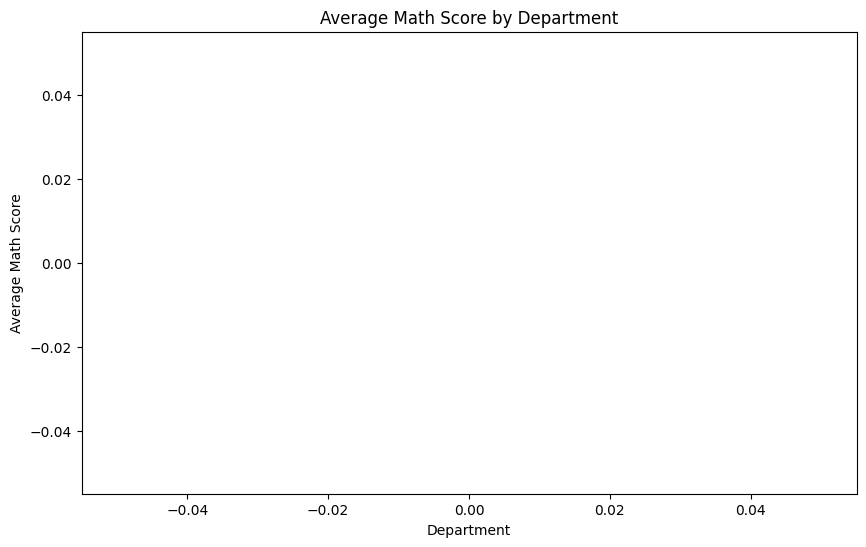

In [103]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('college.db')

chart_sql = """
SELECT department, ROUND(AVG(math_score),2) AS avg_math_score
FROM students
WHERE department IS NOT NULL
GROUP BY department
ORDER BY avg_math_score DESC
"""
chart_data = pd.read_sql_query(chart_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart_data['department'], chart_data['avg_math_score'])
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score by Department')

plt.show()

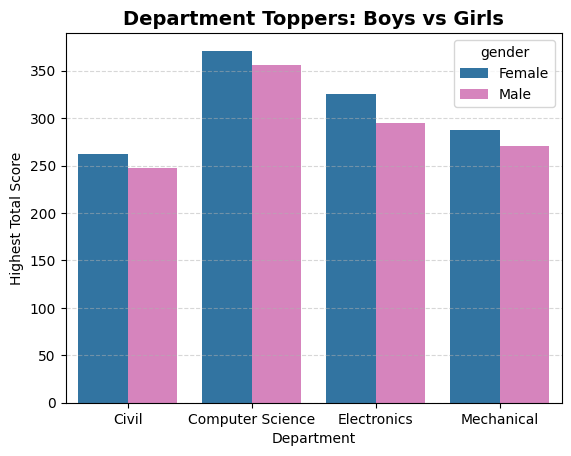

In [104]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('student_performance.csv')


df['total_score'] = df['math_score'] + df['science_score'] + df['english_score'] + df['programming_score']


df_toppers = df.groupby(['department', 'gender'])['total_score'].max().reset_index()


sns.barplot(data=df_toppers, x='department', y='total_score', hue='gender', palette=['#1f77b4', '#e377c2'])


plt.title('Department Toppers: Boys vs Girls', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Highest Total Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)


plt.show()